## Phase 1: Exploratory Data Analysis

In [1]:
import pandas as pd        
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns      

df = pd.read_csv("../data/train.csv")

print(df.head())
print(df.shape)
df.info()

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [2]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [4]:
print("Skewness:", df['SalePrice'].skew())
# Skewness = 1.88, well above 1 -> strongly right-skewed.
# Most houses cluster at moderate prices, but a handful of expensive outliers 
# create a long tail toward high values, pulling this number up from 0.

Skewness: 1.8828757597682129


In [ ]:
print("Log-skewness:", np.log1p(df['SalePrice']).skew())
# Log-skewness = 0.12, close to 0 -> nearly symmetric.
# log1p compressed the long right tail, confirming we should train
# on log1p(SalePrice) instead of raw SalePrice, and reverse with expm1() 
# on predictions before submitting.

Log-skewness: 0.12134661989685333


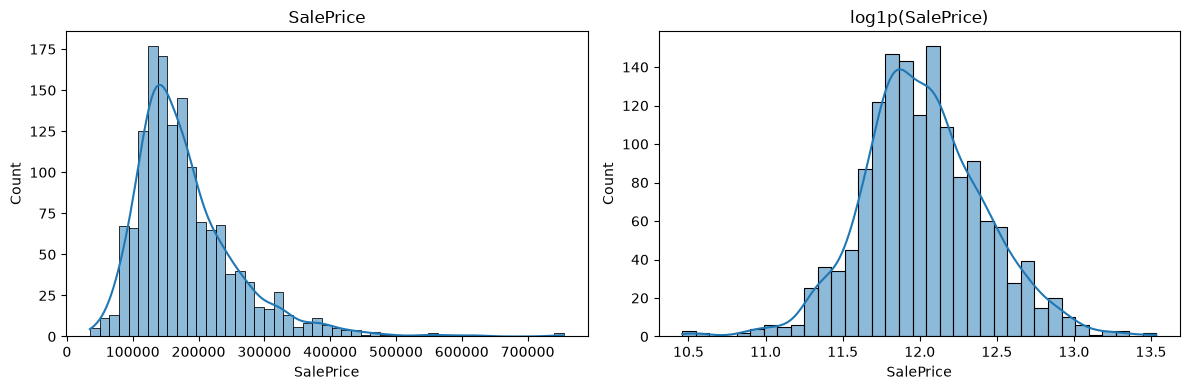

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# creates one figure with 1 row, 2 columns of side-by-side empty plots (12x4 inches total)
# fig = the whole figure, axes = list of the two individual plot areas [axes[0], axes[1]]
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
# draws a histogram of SalePrice (bars = how many houses fall in each price range)
# kde=True overlays a smooth curve showing the estimated distribution shape
# ax=axes[0] draws it into the left subplot created above, instead of a new figure
axes[0].set_title('SalePrice')
#sets the title of the left subplot
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1])
# draws a histogram of SalePrice (bars = how many houses fall in each price range)
# kde=True overlays a smooth curve showing the estimated distribution shape
# ax=axes[1] draws it into the right subplot created above, instead of a new figure
axes[1].set_title('log1p(SalePrice)')
#sets the title of the right subplot
plt.tight_layout()
# automatically adjusts spacing between the two subplots and their titles/labels
# so nothing overlaps or gets cut off at the edges
plt.show()
#displays the figure with the two subplots

## Why we checked skewness and plotted the distributions

**Goal:** decide whether to train the model on raw `SalePrice` or a transformed version.

**Why it matters:** many regression models perform better when the target variable
is roughly symmetric (bell-shaped). A skewed target — where a few extreme values
create a long tail — can distort what the model learns as "typical," since those
extreme values disproportionately affect the loss function.

**What we found:**
- `.describe()` on `SalePrice` showed mean ($180,921) > median ($163,000) — 
  an early sign of right-skew (a small number of expensive houses pulling the average up).
- `.skew()` confirmed this numerically: raw `SalePrice` skewness = **1.88** 
  (strongly right-skewed; anything above 1 is considered highly skewed).
- Applying `log1p()` (log(1 + x)) compresses large values much more than small ones,
  a standard fix for right-skewed data.
- After the transform: `log1p(SalePrice)` skewness = **0.12** (nearly symmetric).

**Visual confirmation:** the side-by-side histograms showed this directly —
raw `SalePrice` has a tall cluster of houses at moderate prices with a long thin
tail stretching toward $750k; `log1p(SalePrice)` looks close to a normal bell curve.

**Decision:** train the model on `log1p(SalePrice)` instead of raw `SalePrice`.
Remember to reverse the transform with `np.expm1()` on predictions before
submitting, to convert back to real dollar values.

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
# selects only the numeric columns from df (ints and floats), 
# dropping text/categorical columns since correlation only works on numbers

corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
# .corr() computes the correlation between every pair of numeric columns,
# returning a full correlation matrix (columns x columns)
# ['SalePrice'] pulls out just one column of that matrix — 
# each numeric feature's correlation with SalePrice specifically
# .sort_values(ascending=False) sorts from strongest positive to weakest/negative

corr
# displays the sorted correlations

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [3]:
# see which columns have missing values, sorted by how many
missing = df.isnull().sum().sort_values(ascending=False)
#df.isnull() : goes through the dataframe and checks if each value is null or not, returns a boolean dataframe, True if null, False if not null
#sum() : sums up the boolean values for each column, True is treated as 1 and False as 0, so it gives the count of missing values for each column
#sort_values(ascending=False) : sorts the resulting series of missing values in descending order, so the columns with the most missing values come first
missing = missing[missing > 0]
#missing[missing > 0] : filters the series to only include columns that have missing values, i.e., where the count of missing values is greater than 0
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [5]:
df[df['PoolQC'].isnull()]['PoolArea'].describe()

count    1453.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: PoolArea, dtype: float64

## Analyzing null values

- PoolQC : Pool Quality, NA = No Pool (verified: PoolArea = 0 for all nulls)
- MiscFeature : NA = None (no elevator, 2nd garage, shed 100+ ft, tennis court, etc.)
- Alley : NA = No alley access
- Fence : NA = No Fence
- FireplaceQu : NA = No Fireplace
- GarageType/GarageFinish/GarageQual/GarageCond : NA = No Garage
- BsmtQual/BsmtCond/BsmtExposure/BsmtFinType1/BsmtFinType2 : NA = No Basement
- LotFrontage : not a documented NA code, genuinely missing → impute median by Neighborhood
- GarageYrBlt : numeric, no garage → fill with 0 or YearBuilt
- MasVnrArea : numeric, likely no veneer → fill with 0
- MasVnrType : "None" is already a valid category (separate from NA) → verify against MasVnrArea before filling
- Electrical : NA not documented, only 1 missing row → impute with mode

In [ ]:
df[df['MasVnrType'].isnull()]['MasVnrArea'].describe() 
# df['MasVnrType'].isnull() : returns a boolean series indicating which rows have missing values in the 'MasVnrType' column
# df[df['MasVnrType'].isnull()] : filters the dataframe to only include rows where 'MasVnrType' is null
# ['MasVnrArea'].describe() : computes summary statistics for the 'MasVnrArea' column of the filtered dataframe,
#  which includes only rows where 'MasVnrType' is null. 
# This will give insights into the distribution of 'MasVnrArea' values for those specific rows.

count    864.000000
mean       1.094907
std       18.569659
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      344.000000
Name: MasVnrArea, dtype: float64

In [ ]:
df[df['MasVnrType'].isnull() & (df['MasVnrArea'] > 0)][['MasVnrType', 'MasVnrArea']]
# df['MasVnrType'].isnull() : returns a boolean series indicating which rows have missing values in the 'MasVnrType' column
#df['MasVnrArea'] > 0 : returns a boolean series indicating which rows have 'MasVnrArea' greater than 0
# & : logical AND operator, combines the two boolean series to find rows where both conditions are true
#[['MasVnrType', 'MasVnrArea']] : selects only the 'MasVnrType' and 'MasVnrArea' columns from the filtered dataframe


,MasVnrType,MasVnrArea
624,NaN,288.0
773,NaN,1.0
1230,NaN,1.0
1300,NaN,344.0
1334,NaN,312.0


## Explaining above result

From 872 rows with an unknown veneer type, 864 had a real area value recorded (most were 0).
The remaining 8 rows had no area value either (missing both columns).
Of the 864, a small number (5) had a nonzero area — these are inconsistent rows,
found separately by filtering for MasVnrArea > 0

In [16]:
mode_type = df['MasVnrType'].mode()[0]
#df['MasVnrType'].mode() : calculates the mode (most frequently occurring value) of the 'MasVnrType' column, returns a Series
#[0] : accesses the first element of the mode Series, which is the most common value
different_values = df['MasVnrType'].isnull() & (df['MasVnrArea'] > 0)
#df['MasVnrType'].isnull() : returns a boolean series indicating which rows have missing values in the 'MasVnrType' column
#df['MasVnrArea'] > 0 : returns a boolean series indicating which rows have 'MasVnrArea' greater than 0
# & : logical AND operator, combines the two boolean series to find rows where both conditions are true, 
# resulting in a boolean series that identifies rows with missing 'MasVnrType' and 'MasVnrArea' greater than 0
df.loc[different_values, 'MasVnrType'] = mode_type
#df.loc[different_values, 'MasVnrType'] : uses the .loc indexer to access the rows in the dataframe where different_values is True and specifically targets the 'MasVnrType' column
# = mode_type : assigns the value of mode_type to the 'MasVnrType'

In [ ]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
#fill any remaining missing values in the 'MasVnrType' column with the string 'None', indicating that there is no masonry veneer type for those entries
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
#fill any remaining missing values in the 'MasVnrArea' column with 0, indicating that there is no masonry veneer area for those entries

In [ ]:
df[['MasVnrType', 'MasVnrArea']].isnull().sum()
#there are no null values anymore in the 'MasVnrType' and 'MasVnrArea' columns, as indicated by the sum of null values being 0 for both columns

MasVnrType    0
MasVnrArea    0
dtype: int64

In [19]:
df[df['FireplaceQu'].isnull()]['Fireplaces'].describe() 

count    690.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Fireplaces, dtype: float64

## Explaining above results

Unlike MasVnrType/MasVnrArea, all rows where FireplaceQu is null have Fireplaces = 0 
(not missing, just zero) — meaning no fireplace, consistently, with no exceptions.
So we simply fill FireplaceQu's null values with the string 'None'.

In [ ]:
df['FireplaceQu'].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

In [ ]:
#since fireplaceQu is a categorical variable, we will fill null values with None
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')

In [25]:
df['FireplaceQu'].isnull().sum()

np.int64(0)

In [26]:
df[df['MiscFeature'].isnull()]['MiscVal'].describe()

count    1406.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: MiscVal, dtype: float64

In [27]:
df['MiscFeature'] = df['MiscFeature'].fillna('None')